In [55]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import spearmanr

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [31]:
annotated_control_df = pd.read_csv('data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar_confident-cellular_drug_context-control.csv')

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_92930/3089952563.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_control_df = pd.read_csv('data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar_confident-cellular_drug_context-control.csv')


In [32]:
annotated_variants_df = annotated_control_df

In [33]:
#Filter for EG
#Keep only rows with EG drugs, cell lines and drop 'MC' source
annotated_variants_df = annotated_variants_df[annotated_variants_df['Drug'].isin(['PIC', 'SCH', 'LIN'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Cell_Line'].isin(['HT29', 'A375'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Source'] != 'MC']

# EDA

In [34]:
annotated_variants_df.shape

(84024, 79)

In [35]:
annotated_variants_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,pocket_id,min_pocket_buriedness,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Neutral,gene_cn_category_Loss,gene_cn_category_Gain,gene_cn_category_Amplification,lnIC50,drug_target_gene_distance,is_drug_target
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,2.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,1.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,10.0,0.848224,-0.290119,0.0,0.0,0.05922,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,0.0,1.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,6.0,0.808046,-0.075387,0.0,0.0,-0.74347,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,1.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,2.0,0.0


In [36]:
#Number of Unique guides
print("Number of Unique guides: ", annotated_variants_df['Guide'].nunique())

Number of Unique guides:  14004


## Analysis of the excluded genes from protvar annotation

In [37]:
excluded_genes_from_protvar = ['KRAS', 'SCH1', 'PRAP1']
excluded_genes_df = annotated_variants_df[annotated_variants_df['Gene'].isin(excluded_genes_from_protvar)]

In [38]:
len(excluded_genes_df)

522

In [39]:
excluded_genes_df['Guide'].nunique()

87

## Analysis of the training (only features) dataset

In [40]:
#Meta data columns
meta_cols=[
    'Target Transcript ID', 'RefSeq match transcript (MANE Select)', 'Guide', 'Editor', 'Gene', 'Cell_Line','Drug', 'Amino Acid Edits',
     'zscore', 'Source', 'uniprot_accession', 'aa_change', 'pocket_id', 'Hit_class'
]

In [41]:
#Filter only training features
annotated_variants_training_df = annotated_variants_df.drop(columns=meta_cols)

In [42]:
annotated_variants_training_df.shape

(84024, 65)

In [43]:
annotated_variants_training_df.head()

,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,min_pocket_buriedness,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Neutral,gene_cn_category_Loss,gene_cn_category_Gain,gene_cn_category_Amplification,lnIC50,drug_target_gene_distance,is_drug_target
0,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,2.0,0.0
1,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,1.0,0.0
2,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,0.848224,-0.290119,0.0,0.0,0.05922,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,0.0,1.0
3,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,0.808046,-0.075387,0.0,0.0,-0.74347,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,1.0,0.0
4,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,2.0,0.0


### Missingness

In [52]:
protvar_features =annotated_variants_training_df[['foldx_ddg', 'min_pocket_buriedness', 'is_in_interface', 'interface_count']]
cellular_features = annotated_variants_training_df[['Gene_expression_voom', 'CRISPR_essentiality_score', 'protein_abundance_zscore',
                                                     'gene_cn_total', 'gene_cn_category_enc', 'gene_cn_category_Neutral',
                                                      'gene_cn_category_Loss', 'gene_cn_category_Gain', 'gene_cn_category_Amplification']]
drug_features = annotated_variants_training_df[['lnIC50', 'drug_target_gene_distance', 'is_drug_target']]


In [54]:
df = drug_features
df_info = pd.DataFrame({
    'dtype': df.dtypes,
    'non-null count': df.notna().sum(),
    'missing count': df.isna().sum(),
    'missing (%)': df.isna().mean() * 100,
    'n_unique': df.nunique(),
    'example': df.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(df)} rows and {len(df.columns)} columns')
df_info

84024 rows and 3 columns


,dtype,non-null count,missing count,missing (%),n_unique,example
lnIC50,float64,84024,0,0.0,6,"[0.311144, -0.905239, 0.724616]"
drug_target_gene_distance,float64,84024,0,0.0,5,"[2.0, 1.0, 0.0]"
is_drug_target,float64,84024,0,0.0,2,"[0.0, 1.0]"


# Correlation Analysis

### Gene expression vs Protein Abundance

In [59]:
protein_expr_df = annotated_variants_df[annotated_variants_df['protein_abundance_zscore'].notna()]

In [87]:
rho, pval = spearmanr(
    annotated_variants_df['gene_cn_total'],
    annotated_variants_df['gene_cn_category_enc']
)

print(f"Spearman rho: {rho:.3f}, p-value: {pval:.2e}")

Spearman rho: 0.997, p-value: 0.00e+00


### Heat Map Continuous Features

In [78]:
annotated_variants_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,pocket_id,min_pocket_buriedness,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Neutral,gene_cn_category_Loss,gene_cn_category_Gain,gene_cn_category_Amplification,lnIC50,drug_target_gene_distance,is_drug_target
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,2.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,1.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,10.0,0.848224,-0.290119,0.0,0.0,0.05922,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,0.0,1.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,6.0,0.808046,-0.075387,0.0,0.0,-0.74347,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,1.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,1.0,0.0,0.0,0.0,0.311144,2.0,0.0


In [81]:
#Encode Classes
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
annotated_variants_df['Class_encoded'] = le.fit_transform(annotated_variants_df['Hit_class'])

In [82]:
continuous_features = [
    'Gene_expression_voom',
    'CRISPR_essentiality_score',
    'gene_cn_total',
    'protein_abundance_zscore',
    'lnIC50',
    'drug_target_gene_distance',
    'foldx_ddg',
    'interface_count',
    'min_pocket_buriedness',
    'zscore',
    'Class_encoded'
]
df_continuous = annotated_variants_df[continuous_features]

In [83]:
corr_spearman = df_continuous.corr(method='spearman')

In [85]:
corr_spearman.head()

,Gene_expression_voom,CRISPR_essentiality_score,gene_cn_total,protein_abundance_zscore,lnIC50,drug_target_gene_distance,foldx_ddg,interface_count,min_pocket_buriedness,zscore,Class_encoded
Gene_expression_voom,1.000000,-0.048453,0.238017,0.311479,-0.034576,0.190500,0.052309,-0.070106,-0.075131,-0.005221,0.001190
CRISPR_essentiality_score,-0.048453,1.000000,-0.082647,0.161925,0.012081,0.075406,0.007194,0.022992,-0.031620,0.006855,0.004013
gene_cn_total,0.238017,-0.082647,1.000000,0.305424,-0.103379,0.123054,0.008070,-0.090146,-0.016402,0.009620,0.035527
protein_abundance_zscore,0.311479,0.161925,0.305424,1.000000,0.017654,0.035143,0.013972,-0.079866,0.020640,0.005334,0.022991
lnIC50,-0.034576,0.012081,-0.103379,0.017654,1.000000,-0.227732,0.000000,0.000000,0.000000,0.064267,-0.013859


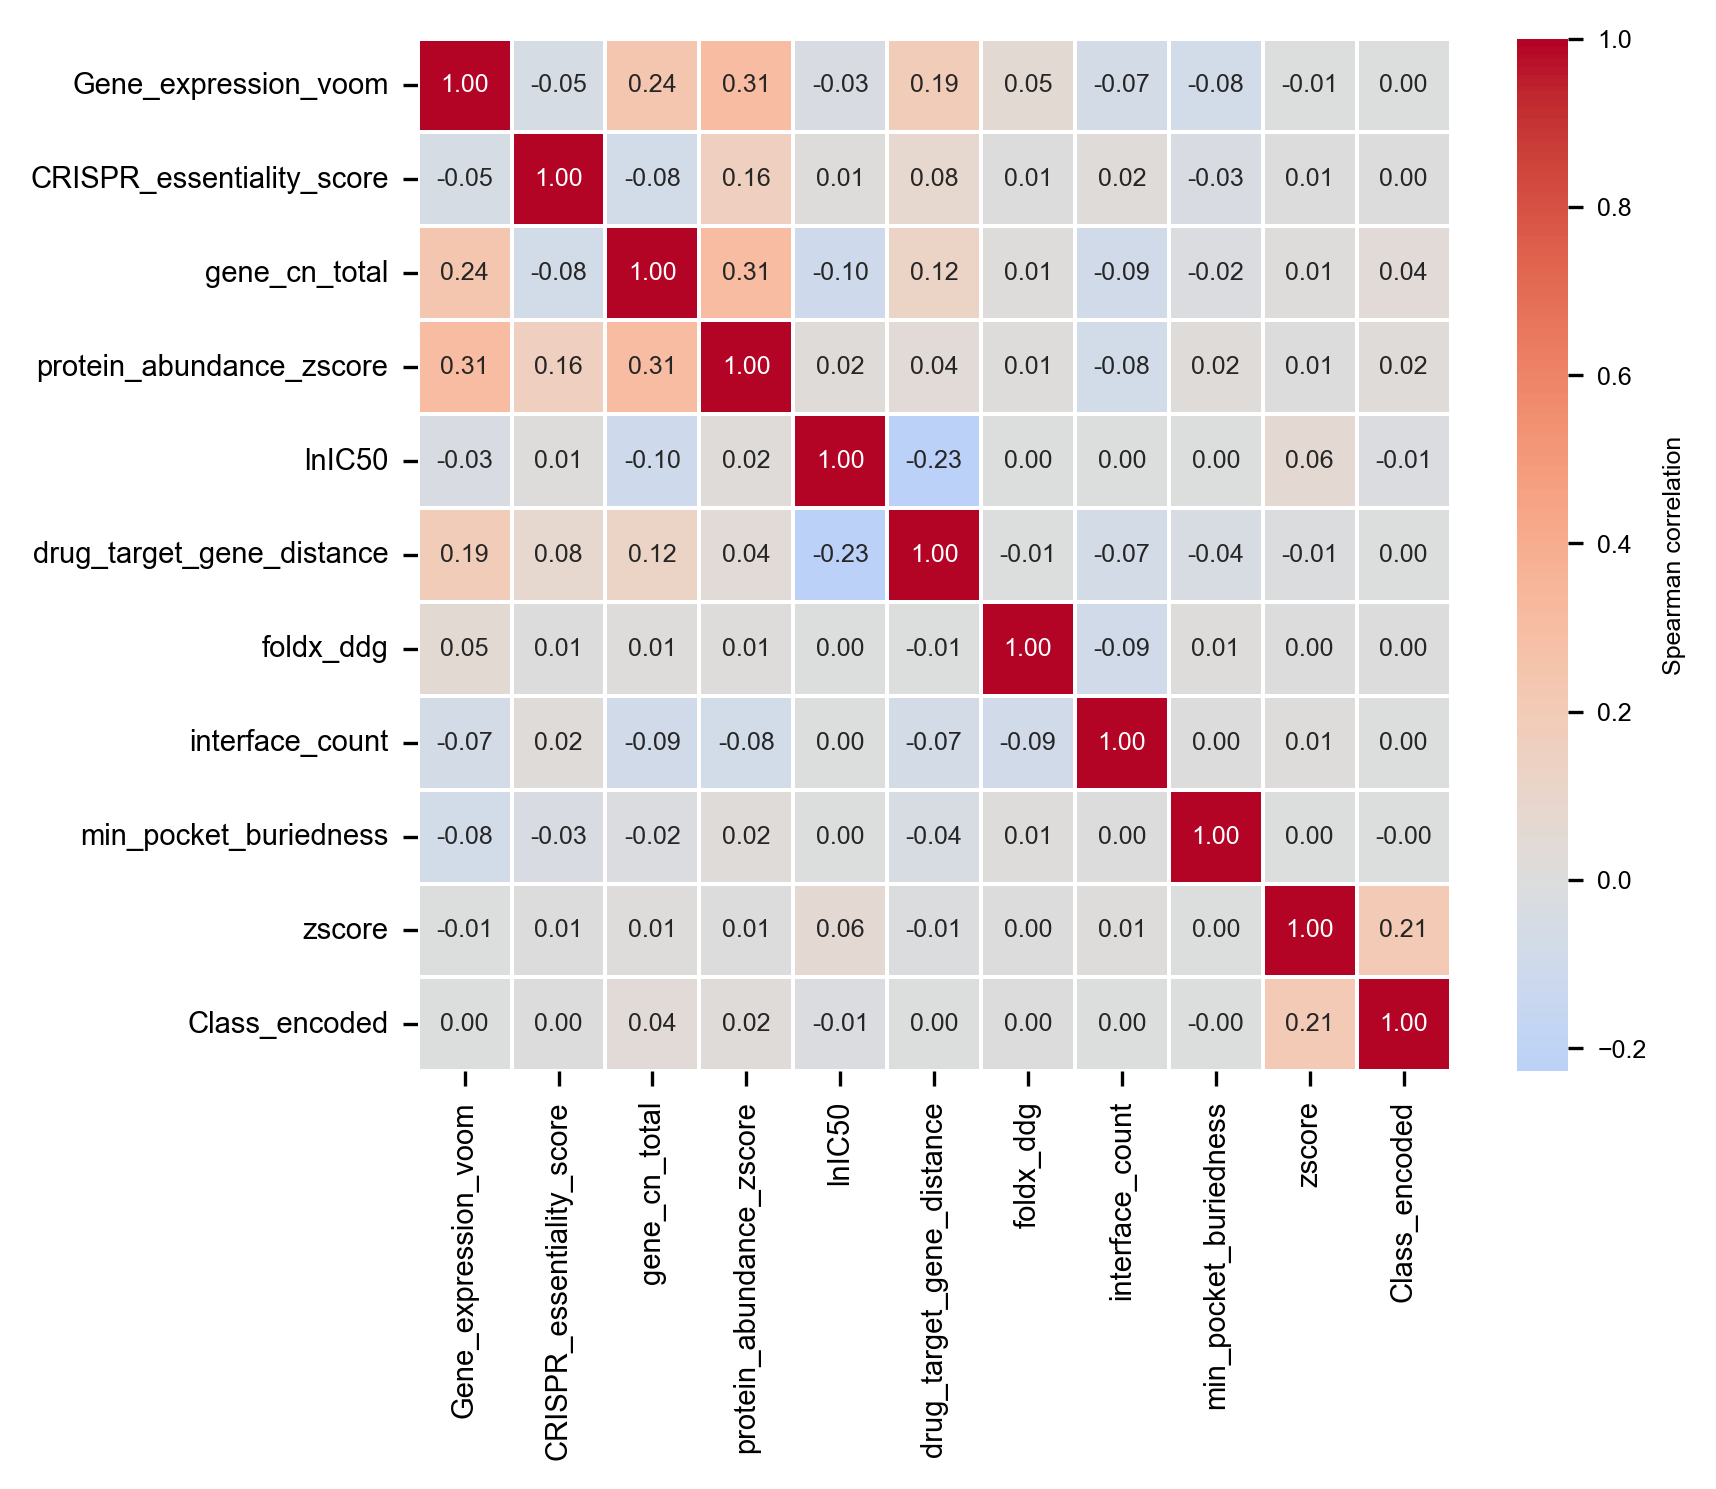

In [84]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_spearman,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,          # ← show numbers
    fmt=".2f",           # ← 2 decimal places
    annot_kws={"size": 6},
    cbar_kws={'label': 'Spearman correlation'}
)

#plt.title('Spearman Correlation Heatmap (Continuous Features)')
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()